# Surrogate Indoor-State Side Experiment — 11.03.2026

This notebook is a **separate side experiment** (outside the core LSTM pipeline) to test whether a simple, dynamic surrogate for indoor thermal state can provide useful inertia-related signals.

The goal is not to estimate true physical parameters directly, but to:

1. Build a compact surrogate indoor-temperature trajectory (`t_in_hat_c`) from outdoor conditions, lagged heat input, and setpoint assumptions.
2. Visualize how this surrogate state moves across daily cycles and weather changes.
3. Produce optional surrogate features (`comfort_deficit_c`, rolling deficits, etc.) for later model experiments.

This creates an additional view for thesis discussion when measured indoor temperature is static/unavailable.


In [1]:
# Cell 0 — Imports, paths, and experiment configuration

from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 11
plt.rcParams["axes.labelsize"] = 10

PROJECT_ROOT = Path.cwd()
CLEAN_DIR = PROJECT_ROOT / "data" / "clean"
RESULTS_DIR = PROJECT_ROOT / "results" / "surrogate_indoor_state"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BUILDINGS = ["U05", "U06", "GEO", "LIB"]
HEAT_SIGNAL_PRIORITY_SUFFIXES = [
    "__weather_driven__energy_delta_mwh",
    "__space_heating__energy_delta_mwh",
    "__total__energy_delta_mwh",
]

# Setpoint assumptions for surrogate state dynamics
SETPOINT_MODE = "day_night"  # "constant" or "day_night"
SETPOINT_CONSTANT_C = 21.0
SETPOINT_DAY_C = 21.0
SETPOINT_NIGHT_C = 20.0
SETPOINT_DAY_START = 6
SETPOINT_DAY_END = 22

# Compact preset set to avoid parameter explosion.
# a: pull to setpoint, b: pull to outdoor, c: lagged heat contribution, d: solar contribution
SURROGATE_PRESETS: Dict[str, Dict[str, float]] = {
    "light_fast": {"a": 0.16, "b": 0.08, "c": 0.10, "d": 0.03},
    "medium": {"a": 0.11, "b": 0.05, "c": 0.07, "d": 0.02},
    "heavy_slow": {"a": 0.07, "b": 0.03, "c": 0.05, "d": 0.015},
}

PLOT_BUILDING = "U06"
PLOT_START = "2024-01-10"
PLOT_END = "2024-01-31"

EXPORT_SURROGATE_TABLES = False
RUN_SIMPLE_LINEAR_CHECK = False

print(f"Project root: {PROJECT_ROOT}")
print(f"Clean dir    : {CLEAN_DIR}")
print(f"Results dir  : {RESULTS_DIR}")
print(f"Buildings    : {BUILDINGS}")
print(f"Setpoint mode: {SETPOINT_MODE}")
print(f"Presets      : {list(SURROGATE_PRESETS.keys())}")


Project root: /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project
Clean dir    : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/clean
Results dir  : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/results/surrogate_indoor_state
Buildings    : ['U05', 'U06', 'GEO', 'LIB']
Setpoint mode: day_night
Presets      : ['light_fast', 'medium', 'heavy_slow']


In [2]:
# Cell 1 — Data loading helpers

def _pick_first_matching_column(columns, suffixes):
    for suffix in suffixes:
        cands = [c for c in columns if c.endswith(suffix)]
        if cands:
            return cands[0]
    return None


def load_clean_building_frame(building: str) -> Tuple[pd.DataFrame, Dict[str, str]]:
    """Load one building clean frame and harmonize to common columns.

    Output columns:
      - heat_kwh
      - outdoor_temp_c
      - solar_wm2
    """
    path = CLEAN_DIR / f"{building}_hourly_merged.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing clean file for {building}: {path}")

    df = pd.read_csv(path, parse_dates=["Time"])

    heat_col = _pick_first_matching_column(df.columns, HEAT_SIGNAL_PRIORITY_SUFFIXES)
    if heat_col is None:
        raise ValueError(f"Could not find heat signal column for {building}")

    if "COP_temp_c" in df.columns:
        temp_col = "COP_temp_c"
    elif "KKP_temp_c" in df.columns:
        temp_col = "KKP_temp_c"
    else:
        raise ValueError(f"Could not find outdoor temperature column for {building}")

    if "COP_ssrd_W_per_m2" in df.columns:
        solar_col = "COP_ssrd_W_per_m2"
    elif "KKP_sunshine_duration_min" in df.columns:
        solar_col = "KKP_sunshine_duration_min"
    else:
        solar_col = None

    keep_cols = ["Time", heat_col, temp_col]
    if solar_col is not None:
        keep_cols.append(solar_col)

    out = df[keep_cols].copy().rename(columns={
        "Time": "datetime",
        heat_col: "heat_mwh",
        temp_col: "outdoor_temp_c",
        solar_col: "solar_wm2" if solar_col is not None else "solar_wm2",
    })

    if "solar_wm2" not in out.columns:
        out["solar_wm2"] = 0.0

    out["heat_kwh"] = out["heat_mwh"] * 1000.0
    out = out.drop(columns=["heat_mwh"]).sort_values("datetime").set_index("datetime")
    out = out.resample("h").mean()

    # Minimal hygiene for side experiment stability
    out["outdoor_temp_c"] = out["outdoor_temp_c"].interpolate(limit_direction="both")
    out["solar_wm2"] = out["solar_wm2"].fillna(0.0).clip(lower=0.0)
    out["heat_kwh"] = out["heat_kwh"].fillna(0.0).clip(lower=0.0)

    meta = {
        "path": str(path),
        "heat_col": heat_col,
        "temp_col": temp_col,
        "solar_col": solar_col if solar_col is not None else "<missing->0>",
    }
    return out, meta


building_frames = {}
building_meta_rows = []

for bldg in BUILDINGS:
    try:
        frame, meta = load_clean_building_frame(bldg)
        building_frames[bldg] = frame
        building_meta_rows.append({
            "building": bldg,
            "rows": int(len(frame)),
            "start": frame.index.min(),
            "end": frame.index.max(),
            "heat_col": meta["heat_col"],
            "temp_col": meta["temp_col"],
            "solar_col": meta["solar_col"],
        })
    except Exception as e:
        print(f"[WARN] {bldg}: {e}")

meta_df = pd.DataFrame(building_meta_rows)
print("Loaded building frames:")
print(meta_df.to_string(index=False))


Loaded building frames:
building  rows               start                 end                              heat_col   temp_col         solar_col
     U05 26275 2022-01-01 00:00:00 2024-12-30 18:00:00 U05__weather_driven__energy_delta_mwh COP_temp_c COP_ssrd_W_per_m2
     U06 26275 2022-01-01 00:00:00 2024-12-30 18:00:00 U06__weather_driven__energy_delta_mwh COP_temp_c COP_ssrd_W_per_m2
     GEO 22886 2022-05-23 10:00:00 2024-12-31 23:00:00 GEO__weather_driven__energy_delta_mwh COP_temp_c COP_ssrd_W_per_m2
     LIB 22955 2022-05-20 12:00:00 2024-12-31 22:00:00 LIB__weather_driven__energy_delta_mwh COP_temp_c COP_ssrd_W_per_m2


In [3]:
# Cell 2 — Surrogate indoor-state dynamics

def build_setpoint_series(index: pd.DatetimeIndex) -> pd.Series:
    if SETPOINT_MODE == "constant":
        return pd.Series(SETPOINT_CONSTANT_C, index=index, dtype=float)

    if SETPOINT_MODE == "day_night":
        hours = index.hour
        is_day = (hours >= SETPOINT_DAY_START) & (hours < SETPOINT_DAY_END)
        vals = np.where(is_day, SETPOINT_DAY_C, SETPOINT_NIGHT_C)
        return pd.Series(vals, index=index, dtype=float)

    raise ValueError(f"Unsupported SETPOINT_MODE: {SETPOINT_MODE}")


def simulate_surrogate_state(df: pd.DataFrame, params: Dict[str, float]) -> Tuple[pd.DataFrame, Dict[str, float]]:
    """Simulate latent indoor-state proxy with first-order dynamics.

    T_in_hat[t+1] = T_in_hat[t]
                  + a*(T_set[t] - T_in_hat[t])
                  + b*(T_out[t] - T_in_hat[t])
                  + c*Q_lag_norm[t]
                  + d*Solar_norm[t]
    """
    out = df.copy()

    out["t_set_c"] = build_setpoint_series(out.index)
    out["heat_lag1_kwh"] = out["heat_kwh"].shift(1).bfill()

    q_scale = float(np.nanpercentile(out["heat_lag1_kwh"], 95))
    if not np.isfinite(q_scale) or q_scale <= 0:
        q_scale = 1.0

    solar_scale = float(np.nanpercentile(out["solar_wm2"], 95))
    if not np.isfinite(solar_scale) or solar_scale <= 0:
        solar_scale = 1.0

    q_norm = (out["heat_lag1_kwh"] / q_scale).values
    solar_norm = (out["solar_wm2"] / solar_scale).values
    t_out = out["outdoor_temp_c"].values
    t_set = out["t_set_c"].values

    a = float(params["a"])
    b = float(params["b"])
    c = float(params["c"])
    d = float(params["d"])

    t_hat = np.empty(len(out), dtype=float)
    t_hat[0] = t_set[0]

    for i in range(1, len(out)):
        prev = t_hat[i - 1]
        t_hat[i] = (
            prev
            + a * (t_set[i - 1] - prev)
            + b * (t_out[i - 1] - prev)
            + c * q_norm[i - 1]
            + d * solar_norm[i - 1]
        )

    t_hat = np.clip(t_hat, 10.0, 30.0)

    out["t_in_hat_c"] = t_hat
    out["t_in_hat_diff1h"] = out["t_in_hat_c"].diff().fillna(0.0)
    out["comfort_deficit_c"] = out["t_set_c"] - out["t_in_hat_c"]
    out["comfort_deficit_roll6h"] = out["comfort_deficit_c"].rolling(6, min_periods=1).mean()

    scales = {
        "q_scale_p95": q_scale,
        "solar_scale_p95": solar_scale,
    }
    return out, scales


simulated_frames = {}
summary_rows = []

for bldg, frame in building_frames.items():
    for preset_name, preset_params in SURROGATE_PRESETS.items():
        sim_df, scales = simulate_surrogate_state(frame, preset_params)
        simulated_frames[(bldg, preset_name)] = sim_df

        amp_daily = float(sim_df["t_in_hat_c"].groupby(sim_df.index.date).agg(lambda x: x.max() - x.min()).median())
        corr_deficit_heat = float(sim_df[["comfort_deficit_c", "heat_kwh"]].corr().iloc[0, 1])

        summary_rows.append({
            "building": bldg,
            "preset": preset_name,
            "mean_t_in_hat_c": float(sim_df["t_in_hat_c"].mean()),
            "std_t_in_hat_c": float(sim_df["t_in_hat_c"].std()),
            "median_daily_amp_c": amp_daily,
            "mean_comfort_deficit_c": float(sim_df["comfort_deficit_c"].mean()),
            "corr(heat, deficit)": corr_deficit_heat,
            "q_scale_p95": scales["q_scale_p95"],
            "solar_scale_p95": scales["solar_scale_p95"],
        })

surrogate_summary_df = pd.DataFrame(summary_rows).sort_values(["building", "preset"]).reset_index(drop=True)
print("Surrogate state summary:")
print(surrogate_summary_df.to_string(index=False))


Surrogate state summary:
building     preset  mean_t_in_hat_c  std_t_in_hat_c  median_daily_amp_c  mean_comfort_deficit_c  corr(heat, deficit)  q_scale_p95  solar_scale_p95
     GEO heavy_slow        17.101256        2.570173            0.910310                3.565527             0.602309         26.0       563.261253
     GEO light_fast        16.669128        2.919071            1.718528                3.997655             0.594405         26.0       563.261253
     GEO     medium        16.926812        2.713035            1.318736                3.739971             0.600817         26.0       563.261253
     LIB heavy_slow        17.096489        2.547841            0.897372                3.570294             0.565611        164.0       564.009840
     LIB light_fast        16.664939        2.899551            1.689432                4.001844             0.571672        164.0       564.009840
     LIB     medium        16.922595        2.692924            1.300602               

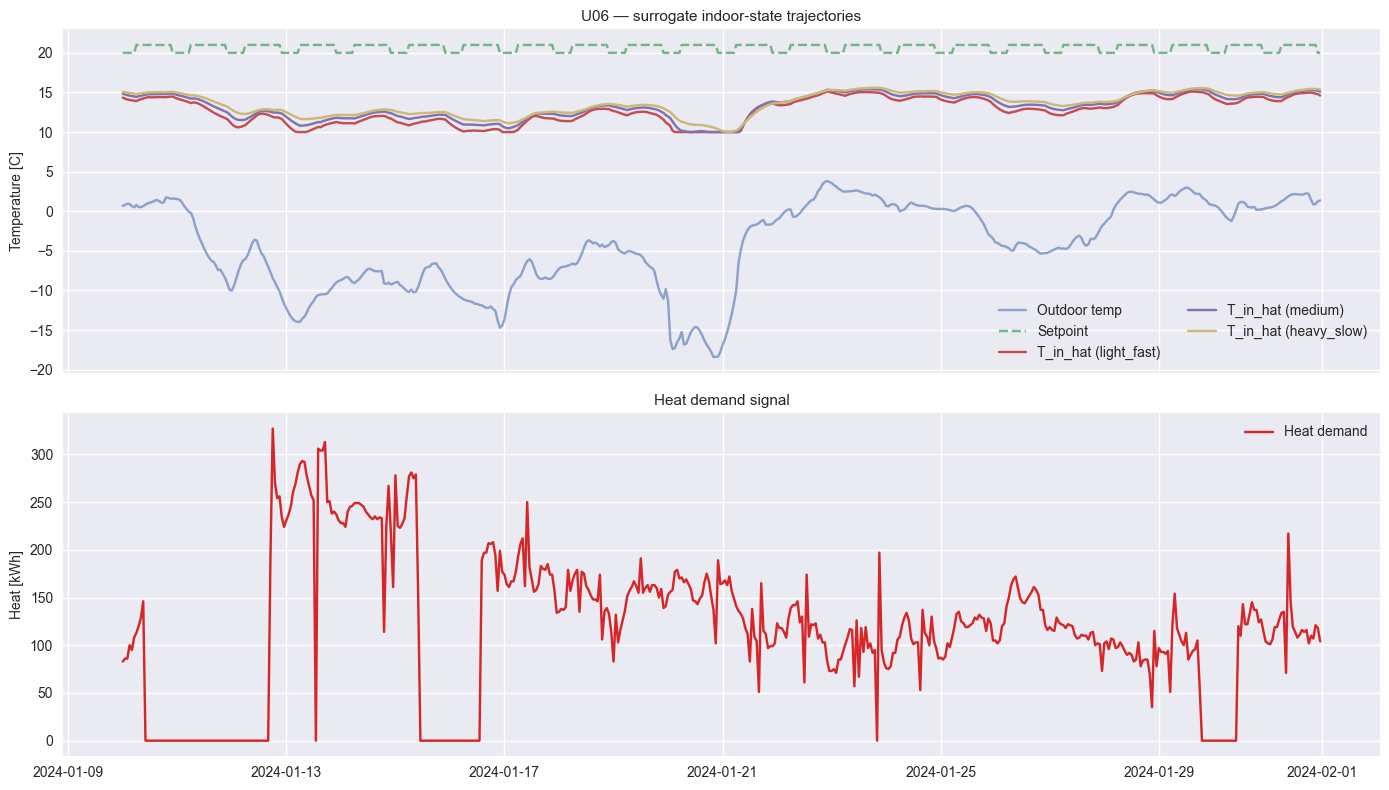

In [4]:
# Cell 3 — Plot: winter window time-series (all presets for one building)

if PLOT_BUILDING not in building_frames:
    print(f"Building {PLOT_BUILDING} not loaded; available: {list(building_frames.keys())}")
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Top: temperatures and surrogate indoor state
    base = simulated_frames[(PLOT_BUILDING, list(SURROGATE_PRESETS.keys())[0])].loc[PLOT_START:PLOT_END]
    axes[0].plot(base.index, base["outdoor_temp_c"], label="Outdoor temp", alpha=0.6)
    axes[0].plot(base.index, base["t_set_c"], label="Setpoint", linestyle="--", alpha=0.8)

    for preset_name in SURROGATE_PRESETS:
        tmp = simulated_frames[(PLOT_BUILDING, preset_name)].loc[PLOT_START:PLOT_END]
        axes[0].plot(tmp.index, tmp["t_in_hat_c"], label=f"T_in_hat ({preset_name})")

    axes[0].set_ylabel("Temperature [C]")
    axes[0].set_title(f"{PLOT_BUILDING} — surrogate indoor-state trajectories")
    axes[0].legend(ncol=2)

    # Bottom: heat demand
    axes[1].plot(base.index, base["heat_kwh"], color="tab:red", label="Heat demand")
    axes[1].set_ylabel("Heat [kWh]")
    axes[1].set_title("Heat demand signal")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


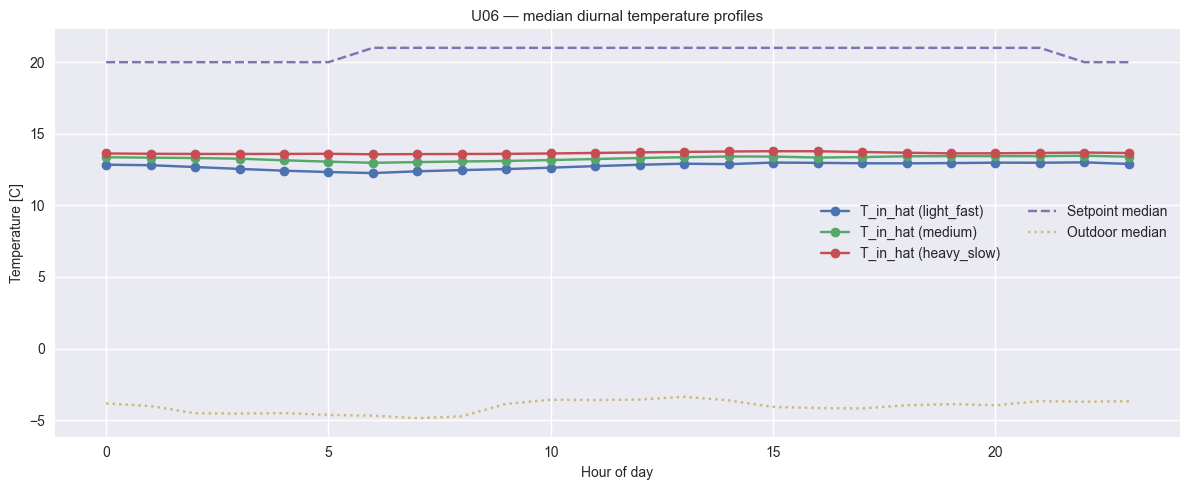

In [5]:
# Cell 4 — Plot: median diurnal profiles by preset

if PLOT_BUILDING not in building_frames:
    print(f"Building {PLOT_BUILDING} not loaded; available: {list(building_frames.keys())}")
else:
    plt.figure(figsize=(12, 5))

    for preset_name in SURROGATE_PRESETS:
        tmp = simulated_frames[(PLOT_BUILDING, preset_name)].loc[PLOT_START:PLOT_END]
        prof = tmp.groupby(tmp.index.hour)["t_in_hat_c"].median()
        plt.plot(prof.index, prof.values, marker="o", label=f"T_in_hat ({preset_name})")

    base = simulated_frames[(PLOT_BUILDING, list(SURROGATE_PRESETS.keys())[0])].loc[PLOT_START:PLOT_END]
    set_prof = base.groupby(base.index.hour)["t_set_c"].median()
    out_prof = base.groupby(base.index.hour)["outdoor_temp_c"].median()

    plt.plot(set_prof.index, set_prof.values, linestyle="--", label="Setpoint median")
    plt.plot(out_prof.index, out_prof.values, linestyle=":", label="Outdoor median")

    plt.xlabel("Hour of day")
    plt.ylabel("Temperature [C]")
    plt.title(f"{PLOT_BUILDING} — median diurnal temperature profiles")
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()


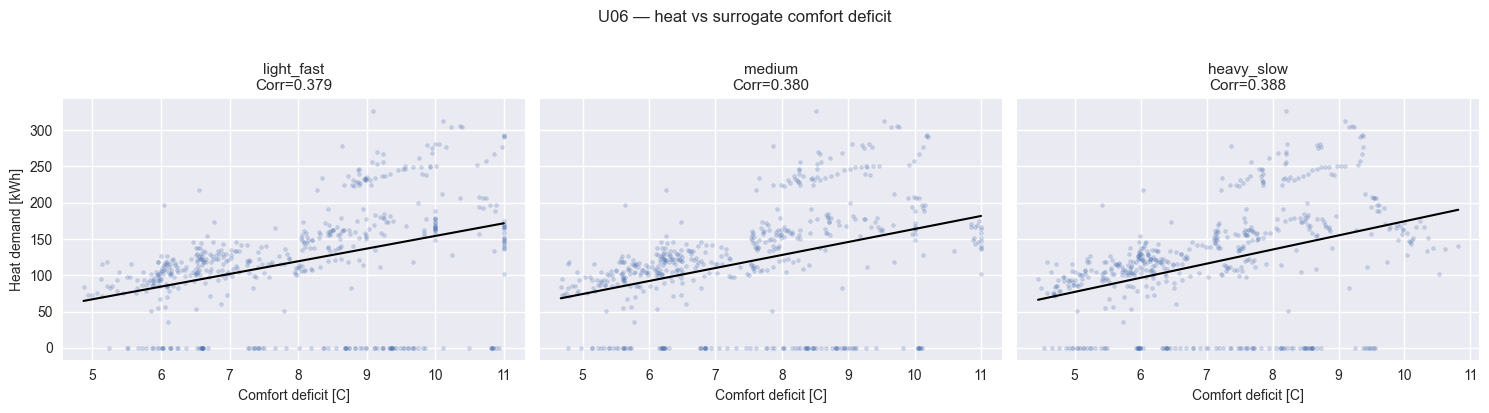

In [6]:
# Cell 5 — Plot: heat demand vs comfort deficit (parameter sensitivity view)

if PLOT_BUILDING not in building_frames:
    print(f"Building {PLOT_BUILDING} not loaded; available: {list(building_frames.keys())}")
else:
    n = len(SURROGATE_PRESETS)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, preset_name in zip(axes, SURROGATE_PRESETS):
        tmp = simulated_frames[(PLOT_BUILDING, preset_name)].loc[PLOT_START:PLOT_END]

        # Thin points for readability
        sample = tmp[["comfort_deficit_c", "heat_kwh"]].dropna()
        if len(sample) > 5000:
            sample = sample.sample(5000, random_state=42)

        ax.scatter(sample["comfort_deficit_c"], sample["heat_kwh"], s=8, alpha=0.25)

        # Simple trend line (visual only)
        if len(sample) > 2:
            x = sample["comfort_deficit_c"].values
            y = sample["heat_kwh"].values
            m, b = np.polyfit(x, y, 1)
            xx = np.linspace(np.nanmin(x), np.nanmax(x), 100)
            ax.plot(xx, m * xx + b, color="black", linewidth=1.5)

        corr = sample[["comfort_deficit_c", "heat_kwh"]].corr().iloc[0, 1]
        ax.set_title(f"{preset_name}\nCorr={corr:.3f}")
        ax.set_xlabel("Comfort deficit [C]")

    axes[0].set_ylabel("Heat demand [kWh]")
    plt.suptitle(f"{PLOT_BUILDING} — heat vs surrogate comfort deficit", y=1.02)
    plt.tight_layout()
    plt.show()


## Reading Guide

- `t_in_hat_c` is a **latent surrogate**, not measured indoor temperature.
- Compare preset behavior by looking at:
  - how quickly `t_in_hat_c` follows outdoor shocks,
  - how strongly comfort deficit tracks heating demand,
  - whether daily cycles look physically plausible.
- If one preset gives more plausible trajectories and stronger stable relation with heat demand,
  use it to generate candidate features for later forecasting/XAI experiments.


In [7]:
# Cell 6 — Optional export of surrogate feature tables

if not EXPORT_SURROGATE_TABLES:
    print("EXPORT_SURROGATE_TABLES=False -> skipping export")
else:
    for (bldg, preset_name), sdf in simulated_frames.items():
        export_cols = [
            "outdoor_temp_c",
            "solar_wm2",
            "heat_kwh",
            "t_set_c",
            "t_in_hat_c",
            "t_in_hat_diff1h",
            "comfort_deficit_c",
            "comfort_deficit_roll6h",
        ]
        out = sdf[export_cols].copy()
        out_path = RESULTS_DIR / f"{bldg}_surrogate_{preset_name}.csv"
        out.to_csv(out_path, index_label="datetime")

    summary_path = RESULTS_DIR / "surrogate_summary.csv"
    surrogate_summary_df.to_csv(summary_path, index=False)

    print(f"Exported surrogate tables to: {RESULTS_DIR}")
    print(f"Summary file: {summary_path}")


EXPORT_SURROGATE_TABLES=False -> skipping export


In [8]:
# Cell 7 — Optional quick predictive check (linear model, no deep learning)

if not RUN_SIMPLE_LINEAR_CHECK:
    print("RUN_SIMPLE_LINEAR_CHECK=False -> skipping quick predictive check")
else:
    from sklearn.linear_model import Ridge
    from sklearn.metrics import mean_squared_error, r2_score

    rows = []

    for bldg in building_frames:
        # Use "medium" preset for quick check
        sdf = simulated_frames[(bldg, "medium")].copy()

        # Train on <=2023, test on >=2024 to mirror split convention
        train_mask = sdf.index <= pd.Timestamp("2023-12-31 23:00:00")
        test_mask = sdf.index >= pd.Timestamp("2024-01-01 00:00:00")

        # Baseline features (weather + hour encoding)
        hour = sdf.index.hour.values
        sdf["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
        sdf["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)

        X_base = sdf[["outdoor_temp_c", "solar_wm2", "hour_sin", "hour_cos"]]
        X_sur = sdf[[
            "outdoor_temp_c", "solar_wm2", "hour_sin", "hour_cos",
            "t_in_hat_c", "comfort_deficit_c", "comfort_deficit_roll6h"
        ]]
        y = sdf["heat_kwh"]

        tr_idx = train_mask & X_sur.notna().all(axis=1) & y.notna()
        te_idx = test_mask & X_sur.notna().all(axis=1) & y.notna()

        if tr_idx.sum() < 1000 or te_idx.sum() < 500:
            continue

        m_base = Ridge(alpha=1.0)
        m_sur = Ridge(alpha=1.0)

        m_base.fit(X_base.loc[tr_idx], y.loc[tr_idx])
        m_sur.fit(X_sur.loc[tr_idx], y.loc[tr_idx])

        pred_base = m_base.predict(X_base.loc[te_idx])
        pred_sur = m_sur.predict(X_sur.loc[te_idx])
        y_true = y.loc[te_idx].values

        def wape(y_t, y_p):
            denom = np.sum(np.abs(y_t))
            if denom <= 0:
                return np.nan
            return 100.0 * np.sum(np.abs(y_t - y_p)) / denom

        rows.append({
            "building": bldg,
            "wape_base": wape(y_true, pred_base),
            "wape_with_surrogate": wape(y_true, pred_sur),
            "delta_wape_pp": wape(y_true, pred_sur) - wape(y_true, pred_base),
            "rmse_base": float(np.sqrt(mean_squared_error(y_true, pred_base))),
            "rmse_with_surrogate": float(np.sqrt(mean_squared_error(y_true, pred_sur))),
            "r2_base": float(r2_score(y_true, pred_base)),
            "r2_with_surrogate": float(r2_score(y_true, pred_sur)),
            "n_test": int(len(y_true)),
        })

    quick_check_df = pd.DataFrame(rows).sort_values("building").reset_index(drop=True)
    print("Quick predictive check (Ridge baseline vs +surrogate features):")
    print(quick_check_df.to_string(index=False))


RUN_SIMPLE_LINEAR_CHECK=False -> skipping quick predictive check


## Final Summary Tables And Discussion Draft

Run these cells after the simulations/plots above. They produce:

1. A detailed per-building/preset results table.
2. A portfolio-level preset comparison table (means, medians, ranks).
3. Auto-generated discussion notes you can reuse in supervisor updates.


In [9]:
# Cell 8 — Consolidated results tables (building-level + portfolio-level)

if "surrogate_summary_df" not in globals() or surrogate_summary_df.empty:
    print("No surrogate_summary_df available. Run Cell 2 first.")
else:
    detail_cols = [
        "building",
        "preset",
        "mean_t_in_hat_c",
        "std_t_in_hat_c",
        "median_daily_amp_c",
        "mean_comfort_deficit_c",
        "corr(heat, deficit)",
    ]

    detail_df = surrogate_summary_df[detail_cols].copy().sort_values(["building", "preset"]).reset_index(drop=True)

    # Rank presets per building by strongest |corr(heat, deficit)|, then lower comfort deficit
    detail_df["abs_corr_heat_def"] = detail_df["corr(heat, deficit)"].abs()
    detail_df["rank_within_building"] = (
        detail_df.sort_values(["building", "abs_corr_heat_def", "mean_comfort_deficit_c"], ascending=[True, False, True])
        .groupby("building")
        .cumcount()
        + 1
    )

    print("Detailed surrogate results (per building, per preset):")
    print(detail_df.to_string(index=False))

    portfolio_table = (
        surrogate_summary_df.groupby("preset", as_index=False)
        .agg(
            n_buildings=("building", "nunique"),
            mean_abs_corr=("corr(heat, deficit)", lambda x: float(np.mean(np.abs(x)))),
            median_abs_corr=("corr(heat, deficit)", lambda x: float(np.median(np.abs(x)))),
            mean_daily_amp_c=("median_daily_amp_c", "mean"),
            mean_comfort_deficit_c=("mean_comfort_deficit_c", "mean"),
            mean_std_t_in_hat_c=("std_t_in_hat_c", "mean"),
        )
    )

    # Heuristic score: reward stronger absolute heat-deficit relation, penalize large comfort deficit.
    portfolio_table["heuristic_score"] = (
        portfolio_table["mean_abs_corr"]
        - 0.05 * portfolio_table["mean_comfort_deficit_c"]
    )
    portfolio_table = portfolio_table.sort_values("heuristic_score", ascending=False).reset_index(drop=True)
    portfolio_table["portfolio_rank"] = np.arange(1, len(portfolio_table) + 1)

    print("\nPortfolio-level preset comparison:")
    print(portfolio_table.to_string(index=False))

    # Optional export
    detail_out = RESULTS_DIR / "surrogate_detail_table.csv"
    portfolio_out = RESULTS_DIR / "surrogate_portfolio_table.csv"
    detail_df.to_csv(detail_out, index=False)
    portfolio_table.to_csv(portfolio_out, index=False)

    print(f"\nSaved: {detail_out}")
    print(f"Saved: {portfolio_out}")


Detailed surrogate results (per building, per preset):
building     preset  mean_t_in_hat_c  std_t_in_hat_c  median_daily_amp_c  mean_comfort_deficit_c  corr(heat, deficit)  abs_corr_heat_def  rank_within_building
     GEO heavy_slow        17.101256        2.570173            0.910310                3.565527             0.602309           0.602309                     1
     GEO light_fast        16.669128        2.919071            1.718528                3.997655             0.594405           0.594405                     3
     GEO     medium        16.926812        2.713035            1.318736                3.739971             0.600817           0.600817                     2
     LIB heavy_slow        17.096489        2.547841            0.897372                3.570294             0.565611           0.565611                     3
     LIB light_fast        16.664939        2.899551            1.689432                4.001844             0.571672           0.571672              

In [10]:
# Cell 9 — Discussion helper text (auto-generated)

if "surrogate_summary_df" not in globals() or surrogate_summary_df.empty:
    print("No surrogate summary found. Run Cell 2 first.")
else:
    # Rebuild a compact portfolio summary if Cell 8 has not been run in this kernel
    if "portfolio_table" not in globals():
        portfolio_table = (
            surrogate_summary_df.groupby("preset", as_index=False)
            .agg(
                n_buildings=("building", "nunique"),
                mean_abs_corr=("corr(heat, deficit)", lambda x: float(np.mean(np.abs(x)))),
                mean_daily_amp_c=("median_daily_amp_c", "mean"),
                mean_comfort_deficit_c=("mean_comfort_deficit_c", "mean"),
            )
        )
        portfolio_table["heuristic_score"] = (
            portfolio_table["mean_abs_corr"] - 0.05 * portfolio_table["mean_comfort_deficit_c"]
        )
        portfolio_table = portfolio_table.sort_values("heuristic_score", ascending=False).reset_index(drop=True)

    best_preset = portfolio_table.iloc[0]["preset"]
    best_score = float(portfolio_table.iloc[0]["heuristic_score"])

    print("Supervisor-ready discussion draft:")
    print("- This side experiment models latent indoor thermal behavior under partial observability (no measured indoor dynamics).")
    print("- Surrogate states were generated with compact parameter presets and compared on physical plausibility and heat-demand linkage.")
    print(f"- Best-performing preset by current heuristic: {best_preset} (score={best_score:.3f}).")
    print("- Key reading: stronger |corr(heat, comfort_deficit)| suggests more informative inertia proxy behavior.")
    print("- This does not estimate true physical HLC/capacitance; it provides assumption-based latent state features for robustness checks.")
    print("- Next step: test whether selected surrogate features improve cold-start horizons (24/72/168/336h) in the revised forecasting matrix.")


Supervisor-ready discussion draft:
- This side experiment models latent indoor thermal behavior under partial observability (no measured indoor dynamics).
- Surrogate states were generated with compact parameter presets and compared on physical plausibility and heat-demand linkage.
- Best-performing preset by current heuristic: heavy_slow (score=0.418).
- Key reading: stronger |corr(heat, comfort_deficit)| suggests more informative inertia proxy behavior.
- This does not estimate true physical HLC/capacitance; it provides assumption-based latent state features for robustness checks.
- Next step: test whether selected surrogate features improve cold-start horizons (24/72/168/336h) in the revised forecasting matrix.


## Suggested Interpretation Structure

Use this structure when presenting:

1. **Why this side experiment exists**: indoor temperature is static in the dataset, so inertia cannot be identified directly.
2. **What was tested**: assumption-based latent indoor-state trajectories with limited parameter presets.
3. **What looked plausible**: compare trajectory smoothness, diurnal amplitude, and comfort-deficit relation to heat demand.
4. **How this connects to ML**: selected surrogate features can be added as additional inertia proxies in later cold-start and ablation runs.
5. **Boundary of claims**: these are surrogate states, not measured indoor conditions or validated physical parameters.
